# Notebook 12 — Dataset Generation & ML Model Training

Generates the meal-misannouncement dataset (10 patients × 200 days) and trains
three classifiers for 30-min hypoglycaemia prediction using LOPO cross-validation.

Outputs saved to `outputs_v14_final_dataset/`.

In [1]:
import sys
print(sys.executable)
%pip install pandas numpy matplotlib joblib scipy scikit-learn simglucose "setuptools<82"

/Users/petermayer/miniconda3/bin/python
Note: you may need to restart the kernel to use updated packages.


In [2]:
# config
N_PATIENTS   = 10
DAYS_PER_PAT = 200
SEED_START   = 12000
WINDOW_MIN   = 90

HORIZON  = 30    # prediction horizon in minutes
CGM_LO   = 70    # hypo threshold
OBS_FLOOR = 80   # only predict when CGM > this

OUT_ROOT = "outputs_v14_final_dataset"
print(f"Config: {N_PATIENTS} patients, {DAYS_PER_PAT} days each")

Config: 10 patients, 200 days each


In [3]:
import os, random
from pathlib import Path
from datetime import datetime, timedelta

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import joblib

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GroupKFold
from sklearn.base import clone
from sklearn.metrics import (
    roc_auc_score, average_precision_score,
    precision_recall_curve,
)

from simglucose.simulation.env import T1DSimEnv
from simglucose.patient.t1dpatient import T1DPatient
from simglucose.sensor.cgm import CGMSensor
from simglucose.actuator.pump import InsulinPump
from simglucose.simulation.scenario import CustomScenario
from simglucose.controller.basal_bolus_ctrller import BBController

# output dirs
OUT   = Path(OUT_ROOT)
TS    = OUT / "timeseries"
FIGS  = OUT / "figures"
CSVS  = OUT / "tables"
MDLS  = OUT / "models"
for d in [OUT, TS, FIGS, CSVS, MDLS]:
    d.mkdir(parents=True, exist_ok=True)

/Users/petermayer/miniconda3/lib/python3.11/site-packages/gym/envs/registration.py:2: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources


In [4]:
# reproducibility
def hard_reset(seed=123):
    os.environ["PYTHONHASHSEED"] = str(seed)
    np.random.seed(seed)
    random.seed(seed)

In [5]:
# find which adult patients simglucose has installed
def discover_patients(max_idx=30):
    found = []
    for i in range(1, max_idx + 1):
        name = f"adult#{i:03d}"
        try:
            T1DPatient.withName(name)
            found.append(name)
        except Exception:
            pass
    return found

ALL_ADULTS = discover_patients()
PATIENTS   = ALL_ADULTS[:N_PATIENTS]
print(f"Using {len(PATIENTS)} patients: {PATIENTS}")

# cycle through skill levels to vary announcement accuracy
SKILLS = {}
for i, p in enumerate(PATIENTS):
    SKILLS[p] = ["good", "avg", "poor"][i % 3]
print("Skill map:", SKILLS)

Using 10 patients: ['adult#001', 'adult#002', 'adult#003', 'adult#004', 'adult#005', 'adult#006', 'adult#007', 'adult#008', 'adult#009', 'adult#010']
Skill map: {'adult#001': 'good', 'adult#002': 'avg', 'adult#003': 'poor', 'adult#004': 'good', 'adult#005': 'avg', 'adult#006': 'poor', 'adult#007': 'good', 'adult#008': 'avg', 'adult#009': 'poor', 'adult#010': 'good'}


In [6]:
# --- scenario generation helpers ---
# these build a realistic day: delays, partial eating, snacks, split meals

def _clip(x, lo, hi):
    return float(max(lo, min(hi, x)))

def partial_eating(schedule, frac_by_time):
    return [(t, float(g) * float(frac_by_time.get(t, 1.0))) for t, g in schedule]

def delay_meals(schedule, delay_by_time):
    out = [(t + timedelta(minutes=int(delay_by_time.get(t, 0))), float(g)) for t, g in schedule]
    return sorted(out, key=lambda x: x[0])

def add_snacks(schedule, snacks):
    return sorted(list(schedule) + [(t, float(g)) for t, g in snacks], key=lambda x: x[0])

def split_meal(schedule, meal_time, frac_now=0.6, delay_min=90):
    out = []
    found = False
    for t, g in schedule:
        if t == meal_time and not found:
            found = True
            g = float(g)
            out.append((t, frac_now * g))
            out.append((t + timedelta(minutes=int(delay_min)), (1 - frac_now) * g))
        else:
            out.append((t, float(g)))
    return sorted(out, key=lambda x: x[0])


def generate_day_scenario(start, rng, base_meals=None, patient_skill="avg"):
    """
    Build one simulated day. Returns the true meal schedule, per-meal k factors,
    and metadata dict.
    """
    if base_meals is None:
        base_meals = [
            (start.replace(hour=8,  minute=0, second=0, microsecond=0), 60.0),
            (start.replace(hour=13, minute=0, second=0, microsecond=0), 80.0),
            (start.replace(hour=19, minute=0, second=0, microsecond=0), 70.0),
        ]

    # skill controls how accurate the patient's carb estimates are
    if patient_skill == "good":
        sd_b, sd_l, sd_d = 0.07, 0.12, 0.15
        p_blunder = 0.03
    elif patient_skill == "poor":
        sd_b, sd_l, sd_d = 0.12, 0.22, 0.28
        p_blunder = 0.08
    else:
        sd_b, sd_l, sd_d = 0.09, 0.16, 0.20
        p_blunder = 0.06

    # pick a day type
    u = rng.random()
    if u < 0.40:   day_type = "normal"
    elif u < 0.60: day_type = "rushed"
    elif u < 0.78: day_type = "under_eat"
    elif u < 0.92: day_type = "takeaway_dinner"
    else:          day_type = "blunder"

    if day_type == "rushed":
        sd_l *= 1.3
        sd_d *= 1.3

    schedule = [(t, float(g)) for t, g in base_meals]

    # random meal delays
    delays = {}
    for t, _ in schedule:
        if day_type in ("rushed", "takeaway_dinner"):
            delays[t] = int(_clip(rng.normal(15, 15), 0, 45))
        else:
            delays[t] = int(_clip(rng.normal(0, 10), -15, 15))
    schedule = delay_meals(schedule, delays)

    meals = sorted(schedule, key=lambda x: x[0])
    t_bk, t_ln, t_dn = meals[0][0], meals[1][0], meals[2][0]

    # under-eating
    under_eat = False
    ue_target, ue_frac = None, 1.0
    if day_type == "under_eat":
        under_eat = True
        ue_target = rng.choice(["lunch", "dinner"])
        ue_frac = float(_clip(rng.normal(0.75, 0.10), 0.55, 0.90))
        frac_map = {t_ln if ue_target == "lunch" else t_dn: ue_frac}
        schedule = partial_eating(schedule, frac_map)

    # split meal (takeaway dinner eaten in two parts)
    do_split, split_frac, split_delay = False, None, None
    if day_type == "takeaway_dinner":
        do_split = True
        split_frac  = float(_clip(rng.normal(0.6, 0.08), 0.45, 0.75))
        split_delay = int(_clip(rng.normal(90, 20), 60, 140))
        schedule = split_meal(schedule, t_dn, frac_now=split_frac, delay_min=split_delay)

    # unannounced snacks
    snack_list = []
    if day_type in ("rushed", "takeaway_dinner", "blunder"):
        n_snk = int(rng.choice([0, 1, 2], p=[0.45, 0.40, 0.15]))
        for _ in range(n_snk):
            hr  = int(rng.choice([15, 16, 17, 20, 21], p=[0.18, 0.22, 0.22, 0.20, 0.18]))
            mn  = int(rng.choice([0, 10, 20, 30, 40, 50]))
            t_s = start.replace(hour=hr, minute=mn, second=0, microsecond=0)
            snack_list.append((t_s, float(_clip(rng.normal(18, 6), 8, 35))))
    schedule = add_snacks(schedule, snack_list)

    # k factors — how much the controller over/under-estimates each meal
    def sample_k(sd):
        k = float(_clip(rng.normal(1.0, sd), 0.6, 1.6))
        if rng.random() < p_blunder or day_type == "blunder":
            k = float(rng.uniform(1.6, 2.4)) if rng.random() < 0.7 else float(rng.uniform(0.35, 0.65))
        return k

    k_bk = sample_k(sd_b)
    k_ln = sample_k(sd_l)
    k_dn = sample_k(sd_d)
    k_map = {t_bk: k_bk, t_ln: k_ln, t_dn: k_dn}

    meta = {
        "day_type": day_type, "patient_skill": patient_skill,
        "delay_breakfast_min": int(delays.get(base_meals[0][0], 0)),
        "delay_lunch_min":     int(delays.get(base_meals[1][0], 0)),
        "delay_dinner_min":    int(delays.get(base_meals[2][0], 0)),
        "k_breakfast": k_bk, "k_lunch": k_ln, "k_dinner": k_dn,
        "under_eat": under_eat,
        "under_eat_target": ue_target or "",
        "under_eat_frac": float(ue_frac),
        "split_meal": do_split,
        "split_frac_now": float(split_frac) if do_split else 0.0,
        "split_delay_min": int(split_delay) if do_split else 0,
        "n_snacks": len(snack_list),
    }
    return schedule, k_map, meta

In [7]:
# meal announcement — the core disturbance mechanism
# instead of modifying patient internals (which simglucose doesn't let you do),
# we scale the carb signal the controller sees for each meal by factor k

def announced_meal_signal(current_time, true_meal, mode="per_meal_k",
                          k_by_mealtime=None, window_min=90):
    true_meal = float(true_meal)
    if true_meal <= 0:
        return 0.0
    if mode != "per_meal_k" or not k_by_mealtime:
        return true_meal

    current_time = pd.Timestamp(current_time)

    # find the closest scheduled meal within the time window
    best_t, best_dt = None, None
    for mt in k_by_mealtime:
        dt = abs((current_time - pd.Timestamp(mt)).total_seconds()) / 60.0
        if best_dt is None or dt < best_dt:
            best_dt = dt
            best_t = mt

    if best_t is not None and best_dt <= window_min:
        return float(k_by_mealtime[best_t]) * true_meal
    return true_meal

In [8]:
# run one 24h closed-loop simulation
def run_closed_loop(patient_name, start_time, schedule_true,
                    mode="per_meal_k", k_by_mealtime=None,
                    window_min=90, seed=123, out_csv=None):
    hard_reset(seed)
    schedule_true = [(t, float(g)) for t, g in list(schedule_true)]
    k_by_mealtime = dict(k_by_mealtime) if k_by_mealtime else {}

    scenario   = CustomScenario(start_time=start_time, scenario=schedule_true)
    patient    = T1DPatient.withName(patient_name)
    sensor     = CGMSensor.withName("Dexcom")
    pump       = InsulinPump.withName("Insulet")
    env        = T1DSimEnv(patient=patient, sensor=sensor, pump=pump, scenario=scenario)
    controller = BBController()

    step  = env.reset()
    t_end = step.info["time"] + timedelta(hours=24)
    rows  = []

    while step.info["time"] < t_end:
        t         = step.info["time"]
        true_meal = float(step.info["meal"])

        ann_meal = announced_meal_signal(
            t, true_meal, mode=mode,
            k_by_mealtime=k_by_mealtime, window_min=window_min)

        action = controller.policy(
            step.observation, step.reward, step.done,
            patient_name=step.info["patient_name"],
            meal=float(ann_meal), sample_time=step.info["sample_time"])

        rows.append({
            "time": t, "CGM": float(step.observation.CGM),
            "BG": float(step.info["bg"]),
            "true_meal_signal": true_meal, "ann_meal_signal": float(ann_meal),
            "basal": float(action.basal), "bolus": float(action.bolus),
        })
        step = env.step(action)

    df = pd.DataFrame(rows)
    if out_csv:
        Path(out_csv).parent.mkdir(parents=True, exist_ok=True)
        df.to_csv(out_csv, index=False)
    return df

In [9]:
# LBGI/HBGI risk metrics (Kovatchev formula)
def glucose_risk_f(bg):
    bg = np.clip(np.asarray(bg, dtype=float), 1.0, None)
    return 1.509 * (np.log(bg) ** 1.084 - 5.381)

def compute_lbgi_hbgi(bg):
    f  = glucose_risk_f(bg)
    rl = 10 * np.minimum(f, 0) ** 2
    rh = 10 * np.maximum(f, 0) ** 2
    return float(np.mean(rl)), float(np.mean(rh))

## Generate dataset

10 patients × 200 days each = 2000 simulated days.  
Each day gets a unique seed so results are reproducible.

In [10]:
START = datetime(2024, 1, 1)

rows_idx = []
rid = 0

for pi, patient in enumerate(PATIENTS):
    print(f"\nRunning {DAYS_PER_PAT} days for {patient}...")
    skill = SKILLS[patient]

    for day in range(DAYS_PER_PAT):
        seed = SEED_START + 1000 * pi + day
        rng  = np.random.default_rng(seed)

        sch_true, k_map, meta = generate_day_scenario(START, rng=rng, patient_skill=skill)

        csv_path = TS / f"{patient}_run{rid:05d}_seed{seed}_STRESS.csv"
        df_day = run_closed_loop(
            patient, START, sch_true,
            k_by_mealtime=k_map, window_min=WINDOW_MIN,
            seed=seed, out_csv=csv_path)

        cgm = df_day["CGM"].astype(float).values
        lbgi, hbgi = compute_lbgi_hbgi(cgm)

        row = {
            "run_id": rid, "patient": patient, "seed": seed, "day_idx": day,
            "day_type": meta["day_type"], "patient_skill": meta["patient_skill"],
            "delay_breakfast_min": meta["delay_breakfast_min"],
            "delay_lunch_min": meta["delay_lunch_min"],
            "delay_dinner_min": meta["delay_dinner_min"],
            "k_breakfast": meta["k_breakfast"],
            "k_lunch": meta["k_lunch"],
            "k_dinner": meta["k_dinner"],
            "under_eat": meta["under_eat"],
            "under_eat_target": meta["under_eat_target"],
            "under_eat_frac": meta["under_eat_frac"],
            "split_meal": meta["split_meal"],
            "split_frac_now": meta["split_frac_now"],
            "split_delay_min": meta["split_delay_min"],
            "n_snacks": meta["n_snacks"],
            "min_CGM": float(np.min(cgm)),
            "TBR_lt70_pct": float(np.mean(cgm < 70) * 100),
            "TBR_lt54_pct": float(np.mean(cgm < 54) * 100),
            "TIR_70_180_pct": float(np.mean((cgm >= 70) & (cgm <= 180)) * 100),
            "TAR_gt180_pct": float(np.mean(cgm > 180) * 100),
            "LBGI": lbgi, "HBGI": hbgi,
        }
        rows_idx.append(row)
        rid += 1

df_index = pd.DataFrame(rows_idx)
df_index.to_csv(OUT / "runs_index.csv", index=False)
print(f"\nDone. {len(df_index)} runs saved.")
display(df_index.head())


Running 200 days for adult#001...

Running 200 days for adult#002...

Running 200 days for adult#003...

Running 200 days for adult#004...

Running 200 days for adult#005...

Running 200 days for adult#006...

Running 200 days for adult#007...

Running 200 days for adult#008...

Running 200 days for adult#009...

Running 200 days for adult#010...

Done. 2000 runs saved.


,run_id,patient,seed,day_idx,day_type,patient_skill,delay_breakfast_min,delay_lunch_min,delay_dinner_min,k_breakfast,...,split_frac_now,split_delay_min,n_snacks,min_CGM,TBR_lt70_pct,TBR_lt54_pct,TIR_70_180_pct,TAR_gt180_pct,LBGI,HBGI
0,0,adult#001,12000,0,under_eat,good,-4,9,3,1.026503,...,0.0,0,0,91.230845,0.0,0.0,91.250000,8.750000,0.113876,2.238782
1,1,adult#001,12001,1,normal,good,-8,7,-6,0.964049,...,0.0,0,0,106.007004,0.0,0.0,88.958333,11.041667,0.001435,3.283104
2,2,adult#001,12002,2,normal,good,0,5,6,2.166611,...,0.0,0,0,79.516587,0.0,0.0,94.791667,5.208333,0.230490,1.540034
3,3,adult#001,12003,3,normal,good,8,4,0,0.919179,...,0.0,0,0,86.893000,0.0,0.0,88.541667,11.458333,0.165564,2.868111
4,4,adult#001,12004,4,rushed,good,15,19,9,1.058265,...,0.0,0,0,71.993119,0.0,0.0,94.166667,5.833333,0.109742,2.398011


In [11]:
# quick sanity check — make sure seeds are unique
assert df_index["seed"].nunique() == len(df_index), "Seed collision!"
print("Seeds OK — all unique")
print(f"Runs with hypo (<70): {(df_index['min_CGM'] < 70).sum()}")
print(f"Runs with severe hypo (<54): {(df_index['min_CGM'] < 54).sum()}")

Seeds OK — all unique
Runs with hypo (<70): 689
Runs with severe hypo (<54): 312


In [12]:
# cohort summary
print("Day type distribution:")
display(df_index["day_type"].value_counts())
print(f"\nUnder-eat: {df_index['under_eat'].mean()*100:.1f}%")
print(f"Split-meal: {df_index['split_meal'].mean()*100:.1f}%")
print(f"Mean snacks/day: {df_index['n_snacks'].mean():.2f}")

Day type distribution:


day_type
normal             784
rushed             410
under_eat          354
takeaway_dinner    292
blunder            160
Name: count, dtype: int64


Under-eat: 17.7%
Split-meal: 14.6%
Mean snacks/day: 0.32


## Feature extraction

Two feature sets:
- **Plain** (7 features): CGM + 30-min rolling stats + 15/30-min deltas
- **Extended** (20 features): adds 15/45/60-min windows, acceleration

In [13]:
def infer_dt(df_ts, default=5):
    if "time" in df_ts.columns:
        try:
            dt = pd.to_datetime(df_ts["time"]).diff().dt.total_seconds().median()
            if pd.notna(dt) and dt > 0:
                return int(round(dt / 60))
        except Exception:
            pass
    return default


def make_features_plain(s, w15, w30):
    return pd.DataFrame({
        "CGM":         s,
        "cgm_mean_30": s.rolling(w30, min_periods=1).mean(),
        "cgm_std_30":  s.rolling(w30, min_periods=1).std().fillna(0),
        "cgm_min_30":  s.rolling(w30, min_periods=1).min(),
        "cgm_max_30":  s.rolling(w30, min_periods=1).max(),
        "cgm_delta_15": s.diff(w15).fillna(0),
        "cgm_delta_30": s.diff(w30).fillna(0),
    })


def make_features_extended(s, w15, w30, w45, w60):
    d15 = s.diff(w15).fillna(0)
    d30 = s.diff(w30).fillna(0)
    d60 = s.diff(w60).fillna(0)
    acc = d15.diff(w15).fillna(0)   # second derivative

    return pd.DataFrame({
        "CGM": s,
        # 15-min
        "cgm_mean_15": s.rolling(w15, min_periods=1).mean(),
        "cgm_std_15":  s.rolling(w15, min_periods=1).std().fillna(0),
        "cgm_min_15":  s.rolling(w15, min_periods=1).min(),
        "cgm_max_15":  s.rolling(w15, min_periods=1).max(),
        # 30-min
        "cgm_mean_30": s.rolling(w30, min_periods=1).mean(),
        "cgm_std_30":  s.rolling(w30, min_periods=1).std().fillna(0),
        "cgm_min_30":  s.rolling(w30, min_periods=1).min(),
        "cgm_max_30":  s.rolling(w30, min_periods=1).max(),
        # 45-min
        "cgm_mean_45": s.rolling(w45, min_periods=1).mean(),
        "cgm_std_45":  s.rolling(w45, min_periods=1).std().fillna(0),
        "cgm_min_45":  s.rolling(w45, min_periods=1).min(),
        # 60-min
        "cgm_mean_60": s.rolling(w60, min_periods=1).mean(),
        "cgm_std_60":  s.rolling(w60, min_periods=1).std().fillna(0),
        "cgm_min_60":  s.rolling(w60, min_periods=1).min(),
        # derivatives
        "cgm_delta_15": d15,
        "cgm_delta_30": d30,
        "cgm_delta_60": d60,
        "cgm_accel_15": acc,
    })


def make_features_and_labels(df_ts, feature_mode="plain",
                              horizon_min=30, cgm_thresh=70, obs_min=80):
    dt = infer_dt(df_ts)
    cgm = df_ts["CGM"].astype(float).values
    n = len(cgm)
    h_steps = max(1, int(round(horizon_min / dt)))
    n_eff = n - h_steps

    if n_eff <= 20:
        return None, None, None, None

    # binary label: will CGM drop below threshold in next horizon?
    y = np.zeros(n_eff, dtype=int)
    for i in range(n_eff):
        if np.min(cgm[i+1 : i+1+h_steps]) < cgm_thresh:
            y[i] = 1

    cgm_used = cgm[:n_eff]
    s = pd.Series(cgm_used)

    w15 = max(1, int(round(15 / dt)))
    w30 = max(1, int(round(30 / dt)))
    w45 = max(1, int(round(45 / dt)))
    w60 = max(1, int(round(60 / dt)))

    if feature_mode == "extended":
        X = make_features_extended(s, w15, w30, w45, w60)
    else:
        X = make_features_plain(s, w15, w30)

    # only predict when CGM is above the observation floor
    mask = cgm_used > obs_min
    X = X.loc[mask].reset_index(drop=True)
    y = y[mask]

    meta = pd.DataFrame({
        "t_idx": np.arange(n_eff)[mask],
        "CGM_true": cgm[:n_eff][mask],
    }).reset_index(drop=True)

    return X, y, meta, dt

In [14]:
# build the ML tables for both feature sets
def build_ml_table(mode):
    chunks_X, chunks_y = [], []

    for _, r in df_index.iterrows():
        csv_path = TS / f"{r['patient']}_run{int(r['run_id']):05d}_seed{int(r['seed'])}_STRESS.csv"
        if not csv_path.exists():
            continue

        X, y, meta, dt = make_features_and_labels(
            pd.read_csv(csv_path), feature_mode=mode,
            horizon_min=HORIZON, cgm_thresh=CGM_LO, obs_min=OBS_FLOOR)
        if X is None:
            continue

        X = X.copy()
        X["patient"]  = r["patient"]
        X["run_id"]   = int(r["run_id"])
        X["seed"]     = int(r["seed"])
        X["dt_min"]   = dt
        X["t_idx"]    = meta["t_idx"].values
        X["CGM_true"] = meta["CGM_true"].values
        chunks_X.append(X)
        chunks_y.append(pd.Series(y, name="y"))

    df_ml = pd.concat(chunks_X, ignore_index=True)
    y_all = pd.concat(chunks_y, ignore_index=True).astype(int)

    meta_cols = ["patient", "run_id", "seed", "dt_min", "t_idx", "CGM_true"]
    feat_cols = [c for c in df_ml.columns if c not in meta_cols]

    print(f"[{mode}] shape={df_ml.shape}, pos rate={y_all.mean()*100:.2f}%")
    df_ml.to_csv(CSVS / f"ml_dataset_{mode}.csv", index=False)
    return df_ml, y_all, feat_cols

print("Building plain features...")
df_plain, y_plain, cols_plain = build_ml_table("plain")

print("Building extended features...")
df_ext, y_ext, cols_ext = build_ml_table("extended")

print(f"\nPlain: {len(cols_plain)} features")
print(f"Extended: {len(cols_ext)} features")

Building plain features...
[plain] shape=(900485, 13), pos rate=0.59%
Building extended features...
[extended] shape=(900485, 25), pos rate=0.59%

Plain: 7 features
Extended: 19 features


## LOPO cross-validation

Each fold holds out one patient entirely — no data leakage.

In [15]:
def run_lopo(df_ml, y_all, feat_cols, pipe, label):
    groups = df_ml["patient"].values
    gkf = GroupKFold(n_splits=df_ml["patient"].nunique())

    results, all_preds = [], []

    for fold, (tr, te) in enumerate(gkf.split(df_ml, y_all, groups=groups), 1):
        Xtr = df_ml.iloc[tr][feat_cols].values
        ytr = y_all.iloc[tr].values
        Xte = df_ml.iloc[te][feat_cols].values
        yte = y_all.iloc[te].values
        pat = df_ml.iloc[te]["patient"].iloc[0]

        clf = clone(pipe)
        clf.fit(Xtr, ytr)
        p = clf.predict_proba(Xte)[:, 1]

        results.append({
            "fold": fold, "test_patient": pat,
            "test_pos_rate_pct": float(yte.mean() * 100),
            "AUROC": float(roc_auc_score(yte, p)),
            "AUPRC": float(average_precision_score(yte, p)),
        })

        tmp = df_ml.iloc[te][["patient", "run_id", "seed", "t_idx", "dt_min"]].copy()
        tmp["y"] = yte
        tmp["p"] = p
        all_preds.append(tmp)

    df_res = pd.DataFrame(results)
    df_preds = pd.concat(all_preds, ignore_index=True)

    pool_auroc = roc_auc_score(df_preds["y"], df_preds["p"])
    pool_auprc = average_precision_score(df_preds["y"], df_preds["p"])

    print(f"\n=== {label} ===")
    display(df_res)
    print(f"Mean AUROC: {df_res['AUROC'].mean():.4f} +/- {df_res['AUROC'].std():.4f}")
    print(f"Mean AUPRC: {df_res['AUPRC'].mean():.4f} +/- {df_res['AUPRC'].std():.4f}")
    print(f"Pooled AUROC: {pool_auroc:.4f} | Pooled AUPRC: {pool_auprc:.4f}")

    return df_res, df_preds, pool_auroc, pool_auprc

In [16]:
# Model A: logistic regression on plain (30-min) features
pipe_A = Pipeline([("scaler", StandardScaler()),
                   ("lr", LogisticRegression(max_iter=4000, class_weight="balanced"))])
res_A, preds_A, auroc_A, auprc_A = run_lopo(
    df_plain, y_plain, cols_plain, pipe_A, "Model A -- LogReg plain")
res_A.to_csv(CSVS / "lopo_modelA_results.csv", index=False)
preds_A.to_csv(CSVS / "lopo_modelA_predictions.csv", index=False)


=== Model A -- LogReg plain ===


,fold,test_patient,test_pos_rate_pct,AUROC,AUPRC
0,1,adult#002,0.194643,0.976723,0.108425
1,2,adult#001,0.327819,0.981644,0.126713
2,3,adult#010,0.442749,0.984934,0.183997
3,4,adult#007,0.449478,0.975946,0.130189
4,5,adult#009,0.588118,0.977925,0.229072
5,6,adult#006,0.584405,0.985493,0.249817
6,7,adult#004,0.879528,0.963317,0.308595
7,8,adult#008,0.734931,0.971793,0.186965
8,9,adult#005,0.635006,0.969147,0.201741
9,10,adult#003,1.088552,0.975454,0.336780


Mean AUROC: 0.9762 +/- 0.0069
Mean AUPRC: 0.2062 +/- 0.0764
Pooled AUROC: 0.9767 | Pooled AUPRC: 0.2206


In [17]:
# Model B: logistic regression on extended features
pipe_B = Pipeline([("scaler", StandardScaler()),
                   ("lr", LogisticRegression(max_iter=4000, class_weight="balanced"))])
res_B, preds_B, auroc_B, auprc_B = run_lopo(
    df_ext, y_ext, cols_ext, pipe_B, "Model B -- LogReg extended")
res_B.to_csv(CSVS / "lopo_modelB_results.csv", index=False)
preds_B.to_csv(CSVS / "lopo_modelB_predictions.csv", index=False)


=== Model B -- LogReg extended ===


,fold,test_patient,test_pos_rate_pct,AUROC,AUPRC
0,1,adult#002,0.194643,0.976401,0.113189
1,2,adult#001,0.327819,0.984791,0.161039
2,3,adult#010,0.442749,0.986378,0.206225
3,4,adult#007,0.449478,0.978468,0.196314
4,5,adult#009,0.588118,0.980123,0.267938
5,6,adult#006,0.584405,0.986986,0.260451
6,7,adult#004,0.879528,0.971480,0.395001
7,8,adult#008,0.734931,0.974622,0.210477
8,9,adult#005,0.635006,0.975315,0.253798
9,10,adult#003,1.088552,0.979113,0.393765


Mean AUROC: 0.9794 +/- 0.0052
Mean AUPRC: 0.2458 +/- 0.0913
Pooled AUROC: 0.9801 | Pooled AUPRC: 0.2689


In [18]:
# Model C: random forest on extended features
pipe_C = Pipeline([
    ("scaler", StandardScaler()),  # RF doesn't need this but keeps pipeline consistent
    ("rf", RandomForestClassifier(
        n_estimators=300, max_depth=None, min_samples_leaf=10,
        class_weight="balanced", n_jobs=-1, random_state=42)),
])
res_C, preds_C, auroc_C, auprc_C = run_lopo(
    df_ext, y_ext, cols_ext, pipe_C, "Model C -- Random Forest extended")
res_C.to_csv(CSVS / "lopo_modelC_results.csv", index=False)
preds_C.to_csv(CSVS / "lopo_modelC_predictions.csv", index=False)


=== Model C -- Random Forest extended ===


,fold,test_patient,test_pos_rate_pct,AUROC,AUPRC
0,1,adult#002,0.194643,0.954163,0.127912
1,2,adult#001,0.327819,0.974298,0.138413
2,3,adult#010,0.442749,0.981172,0.179934
3,4,adult#007,0.449478,0.967090,0.151741
4,5,adult#009,0.588118,0.967849,0.191598
5,6,adult#006,0.584405,0.983140,0.267108
6,7,adult#004,0.879528,0.956887,0.303952
7,8,adult#008,0.734931,0.969559,0.190126
8,9,adult#005,0.635006,0.957424,0.194431
9,10,adult#003,1.088552,0.967924,0.330749


Mean AUROC: 0.9680 +/- 0.0098
Mean AUPRC: 0.2076 +/- 0.0697
Pooled AUROC: 0.9692 | Pooled AUPRC: 0.2170


In [19]:
# head-to-head comparison
comparison = pd.DataFrame([
    {"model": "A - LogReg plain",  "features": "plain (30-min)",
     "mean_AUROC": res_A["AUROC"].mean(), "std_AUROC": res_A["AUROC"].std(),
     "mean_AUPRC": res_A["AUPRC"].mean(), "std_AUPRC": res_A["AUPRC"].std(),
     "pooled_AUROC": auroc_A, "pooled_AUPRC": auprc_A},
    {"model": "B - LogReg extended", "features": "extended (60-min)",
     "mean_AUROC": res_B["AUROC"].mean(), "std_AUROC": res_B["AUROC"].std(),
     "mean_AUPRC": res_B["AUPRC"].mean(), "std_AUPRC": res_B["AUPRC"].std(),
     "pooled_AUROC": auroc_B, "pooled_AUPRC": auprc_B},
    {"model": "C - RF extended", "features": "extended (60-min)",
     "mean_AUROC": res_C["AUROC"].mean(), "std_AUROC": res_C["AUROC"].std(),
     "mean_AUPRC": res_C["AUPRC"].mean(), "std_AUPRC": res_C["AUPRC"].std(),
     "pooled_AUROC": auroc_C, "pooled_AUPRC": auprc_C},
])
display(comparison)
comparison.to_csv(CSVS / "model_comparison.csv", index=False)

# pick best by pooled AUROC and retrain on full dataset
best_idx = comparison["pooled_AUROC"].idxmax()
best_label = comparison.loc[best_idx, "model"]
print(f"\nBest model: {best_label}")

if best_idx == 0:
    best_pipe, best_df, best_y, best_cols = pipe_A, df_plain, y_plain, cols_plain
elif best_idx == 1:
    best_pipe, best_df, best_y, best_cols = pipe_B, df_ext, y_ext, cols_ext
else:
    best_pipe, best_df, best_y, best_cols = pipe_C, df_ext, y_ext, cols_ext

final_model = clone(best_pipe)
final_model.fit(best_df[best_cols].values, best_y.values)

joblib.dump(final_model, MDLS / "best_model.joblib")
joblib.dump(best_cols,   MDLS / "best_feature_cols.joblib")
joblib.dump(best_label,  MDLS / "best_model_label.joblib")
print(f"Saved to {MDLS}")

,model,features,mean_AUROC,std_AUROC,mean_AUPRC,std_AUPRC,pooled_AUROC,pooled_AUPRC
0,A - LogReg plain,plain (30-min),0.976238,0.006923,0.206229,0.076376,0.976701,0.220621
1,B - LogReg extended,extended (60-min),0.979368,0.005249,0.245820,0.091260,0.980102,0.268920
2,C - RF extended,extended (60-min),0.967951,0.009846,0.207596,0.069720,0.969231,0.216961



Best model: B - LogReg extended
Saved to outputs_v14_final_dataset/models


## Report figures

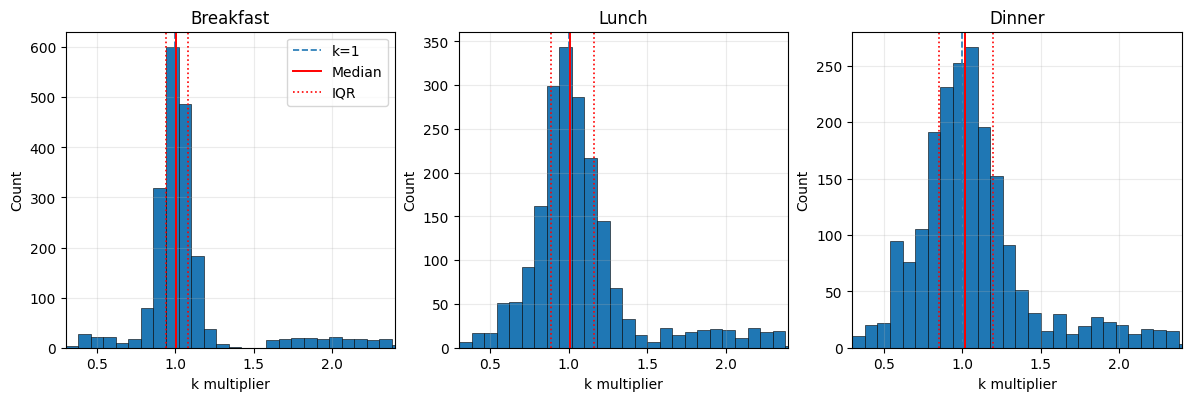

In [20]:
# k-multiplier distributions
fig, axes = plt.subplots(1, 3, figsize=(11.8, 3.9), constrained_layout=True)
for ax, col, title in zip(axes, ["k_breakfast", "k_lunch", "k_dinner"],
                                 ["Breakfast", "Lunch", "Dinner"]):
    vals = df_index[col].dropna()
    vals = vals[(vals >= 0.3) & (vals <= 2.4)]
    bins = np.arange(0.3, 2.48, 0.08)
    ax.hist(vals, bins=bins, edgecolor="black", linewidth=0.4)
    ax.axvline(1.0, ls="--", lw=1.2, label="k=1")
    ax.axvline(vals.median(), color="red", lw=1.4, label="Median")
    ax.axvline(vals.quantile(0.25), color="red", ls=":", lw=1.2, label="IQR")
    ax.axvline(vals.quantile(0.75), color="red", ls=":", lw=1.2)
    ax.set_title(title)
    ax.set_xlabel("k multiplier")
    ax.set_ylabel("Count")
    ax.set_xlim(0.3, 2.4)
    ax.grid(True, alpha=0.25)
axes[0].legend()
fig.savefig(FIGS / "ch4_k_multipliers.png", dpi=300, bbox_inches="tight")
plt.show()

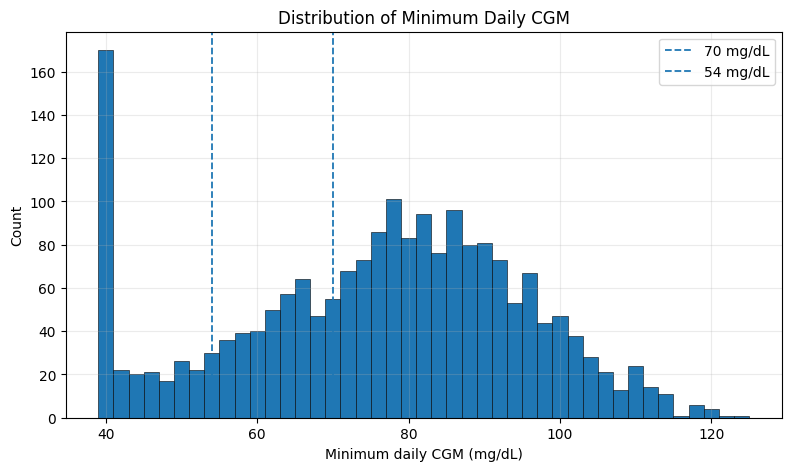

In [21]:
# min daily CGM histogram
vals = df_index["min_CGM"].dropna()
fig, ax = plt.subplots(figsize=(7.8, 4.6), constrained_layout=True)
bins = np.arange(int(np.floor(vals.min())), int(np.ceil(vals.max())) + 2, 2)
ax.hist(vals, bins=bins, edgecolor="black", linewidth=0.4)
ax.axvline(70, ls="--", lw=1.3, label="70 mg/dL")
ax.axvline(54, ls="--", lw=1.3, label="54 mg/dL")
ax.set_title("Distribution of Minimum Daily CGM")
ax.set_xlabel("Minimum daily CGM (mg/dL)")
ax.set_ylabel("Count")
ax.legend()
ax.grid(True, alpha=0.25)
fig.savefig(FIGS / "ch5_min_daily_cgm.png", dpi=300, bbox_inches="tight")
plt.show()

,day_type,n,hypo_pct,severe_pct,mean_min
0,blunder,160,91.88,80.00,46.65
4,under_eat,354,32.49,11.86,77.57
2,rushed,410,31.46,11.71,77.45
3,takeaway_dinner,292,28.08,8.56,78.46
1,normal,784,27.55,8.80,79.07


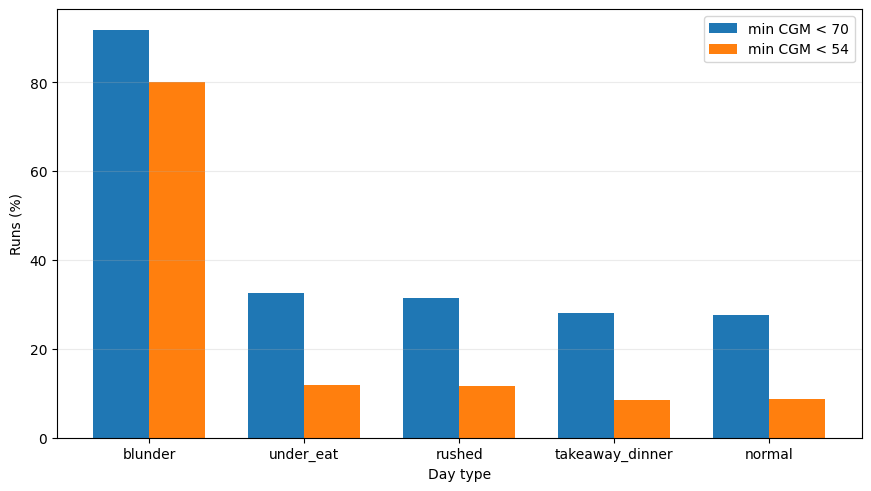

In [22]:
# hypo rate by day type
dt_stats = (df_index.groupby("day_type").agg(
    n=("run_id", "count"),
    hypo_pct=("min_CGM", lambda x: 100 * np.mean(x < 70)),
    severe_pct=("min_CGM", lambda x: 100 * np.mean(x < 54)),
    mean_min=("min_CGM", "mean"),
).reset_index().sort_values("hypo_pct", ascending=False))

display(dt_stats.round(2))

fig, ax = plt.subplots(figsize=(8.6, 4.8), constrained_layout=True)
x = np.arange(len(dt_stats))
w = 0.36
ax.bar(x - w/2, dt_stats["hypo_pct"], w, label="min CGM < 70")
ax.bar(x + w/2, dt_stats["severe_pct"], w, label="min CGM < 54")
ax.set_xticks(x)
ax.set_xticklabels(dt_stats["day_type"])
ax.set_ylabel("Runs (%)")
ax.set_xlabel("Day type")
ax.legend()
ax.grid(axis="y", alpha=0.25)
fig.savefig(FIGS / "ch5_hypo_by_daytype.png", dpi=300, bbox_inches="tight")
plt.show()

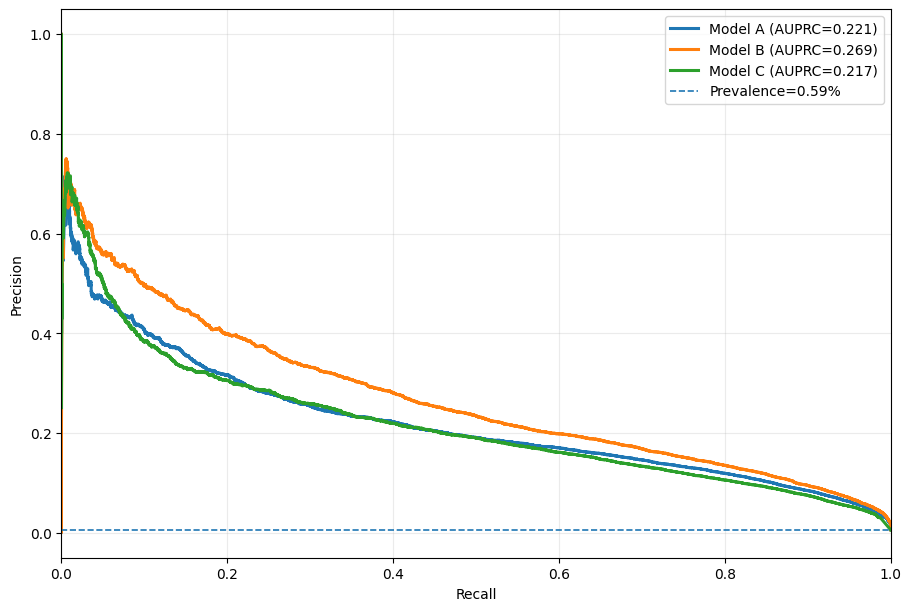

In [23]:
# precision-recall curves
fig, ax = plt.subplots(figsize=(9, 6), constrained_layout=True)
for preds, lbl in [(preds_A, "A"), (preds_B, "B"), (preds_C, "C")]:
    prec, rec, _ = precision_recall_curve(preds["y"], preds["p"])
    ap = average_precision_score(preds["y"], preds["p"])
    ax.plot(rec, prec, lw=2.2, label=f"Model {lbl} (AUPRC={ap:.3f})")
prev = preds_B["y"].mean()
ax.axhline(prev, ls="--", lw=1.2, label=f"Prevalence={100*prev:.2f}%")
ax.set_xlabel("Recall")
ax.set_ylabel("Precision")
ax.set_xlim(0, 1)
ax.legend(loc="upper right")
ax.grid(True, alpha=0.25)
fig.savefig(FIGS / "ch5_pr_curves.png", dpi=300, bbox_inches="tight")
plt.show()

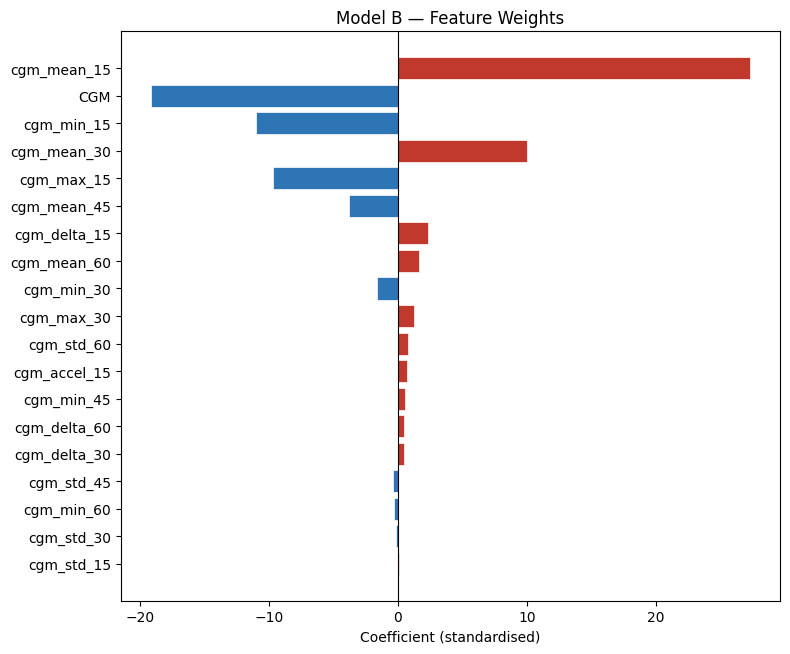

In [24]:
# feature importance — logistic regression coefficients for Model B

pipe_B_fitted = clone(pipe_B)
pipe_B_fitted.fit(df_ext[cols_ext].values, y_ext.values)

lr = pipe_B_fitted.named_steps["lr"]
coefs = lr.coef_[0]

df_coef = pd.DataFrame({"feature": cols_ext, "coef": coefs})
df_coef["abs"] = df_coef["coef"].abs()
df_coef = df_coef.sort_values("abs", ascending=True)

fig, ax = plt.subplots(figsize=(8, max(5, len(df_coef) * 0.35)))
colors = ["#c0392c" if c > 0 else "#2e75b6" for c in df_coef["coef"]]
ax.barh(df_coef["feature"], df_coef["coef"], color=colors, edgecolor="white", lw=0.5)
ax.axvline(0, color="black", lw=0.8)
ax.set_xlabel("Coefficient (standardised)")
ax.set_title("Model B — Feature Weights")
plt.tight_layout()
fig.savefig(FIGS / "ch6_feature_importance.png", dpi=200, bbox_inches="tight")
plt.show()